In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [6]:
import pandas as pd

# Lire le fichier CSV correctement
df = pd.read_csv(r"C:\Users\lenovo\Downloads\diabetes.csv")


In [7]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [8]:
# Afficher les premières lignes
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [9]:

# Afficher des informations sur les colonnes
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [10]:
# Statistiques descriptives
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [11]:
print("Nombre de lignes (échantillons) :", df.shape[0])
print("Nombre de colonnes (variables) :", df.shape[1])


Nombre de lignes (échantillons) : 768
Nombre de colonnes (variables) : 9


In [12]:
print("Dimensions du dataset :", df.shape)


Dimensions du dataset : (768, 9)


In [13]:
print("Nombre total de valeurs manquantes :", df.isnull().sum().sum())

Nombre total de valeurs manquantes : 0


In [14]:
# Colonnes concernées
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Afficher le nombre de zéros par colonne
for col in cols_with_zero:
    zero_count = (df[col] == 0).sum()
    print(f"Nombre de zéros dans {col}: {zero_count}")


Nombre de zéros dans Glucose: 5
Nombre de zéros dans BloodPressure: 35
Nombre de zéros dans SkinThickness: 227
Nombre de zéros dans Insulin: 374
Nombre de zéros dans BMI: 11


In [15]:
# Remplacer les zéros par la médiane dans les colonnes concernées
for col in cols_with_zero:
    median_value = df[col].median()  # Calcul de la médiane
    df[col] = df[col].replace(0, median_value)  # Remplacer les zéros par la médiane


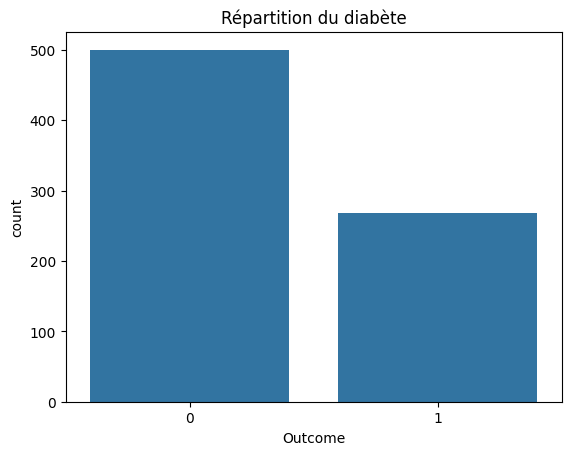

In [17]:
sns.countplot(x="Outcome", data=df)
plt.title("Répartition du diabète")
plt.show()

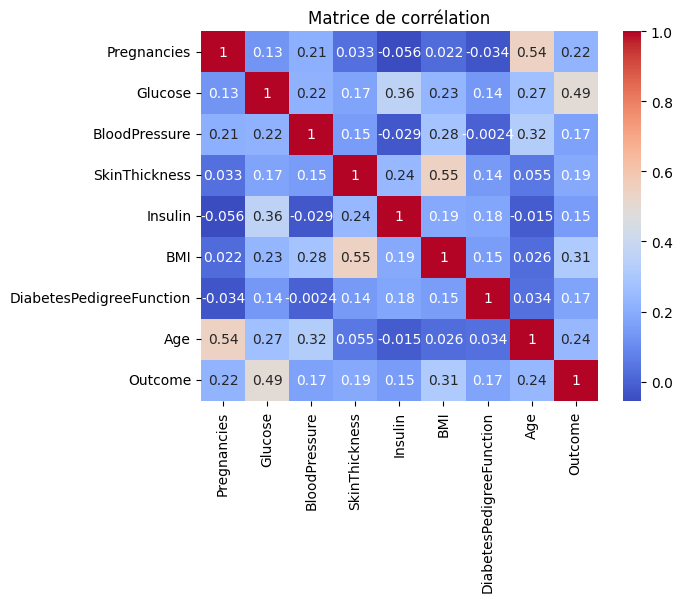

In [18]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

In [19]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [22]:
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154

ROC AUC Score: 0.820925925925926


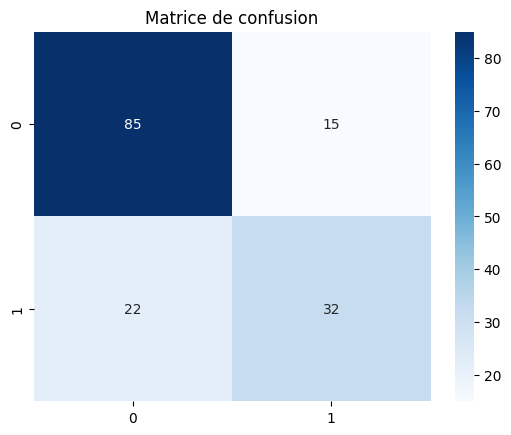

In [23]:
# Matrice de confusion
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.show()

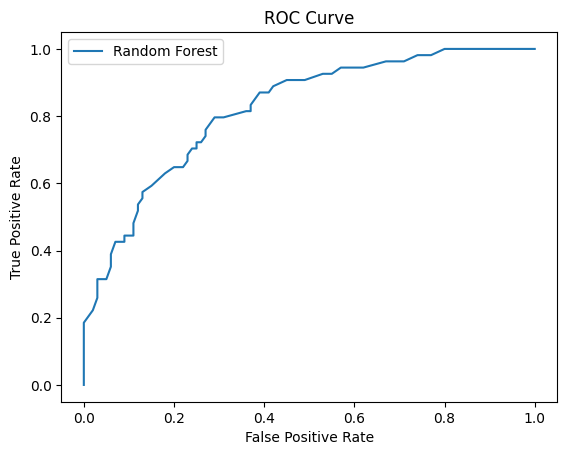

In [24]:
# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label="Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [27]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from imblearn.over_sampling import SMOTE

# Appliquer SMOTE pour équilibrer les classes
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

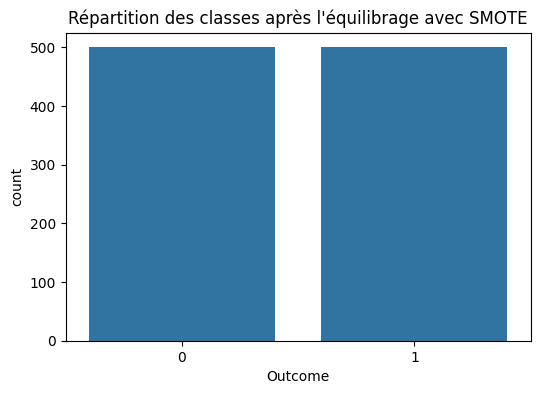

In [31]:
# Afficher la répartition des classes après l'équilibrage
plt.figure(figsize=(6, 4))
sns.countplot(x=y_res)
plt.title("Répartition des classes après l'équilibrage avec SMOTE")
plt.show()


Classification Report (avec SMOTE) :
              precision    recall  f1-score   support

           0       0.87      0.77      0.81       100
           1       0.79      0.88      0.83       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



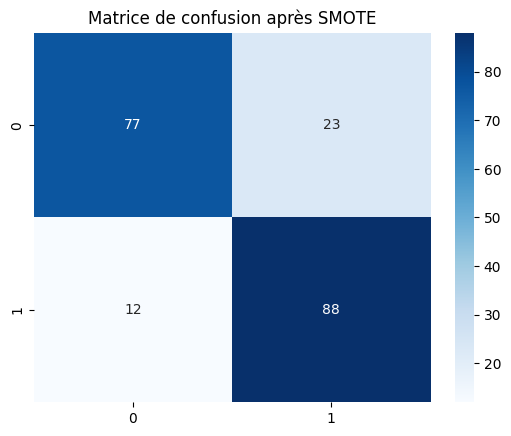

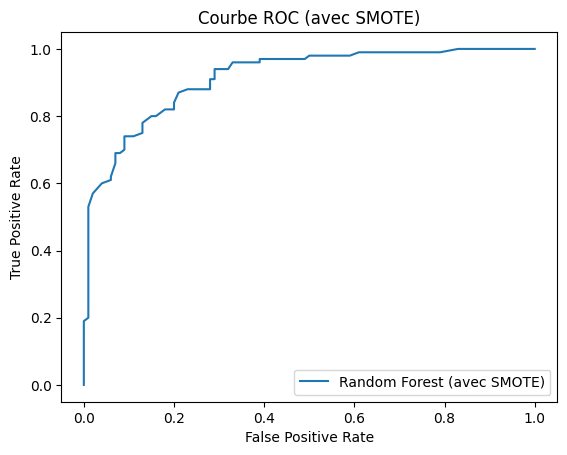

ROC AUC Score (avec SMOTE) : 0.9147


In [32]:
# Réentraîner le modèle avec les données rééchantillonnées (X_res, y_res)
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

# Appliquer la normalisation aux données rééchantillonnées
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_res_scaled = scaler.transform(X_test_res)

# Entraîner le modèle avec les données équilibrées
model.fit(X_train_res_scaled, y_train_res)
y_pred_res = model.predict(X_test_res_scaled)

# Évaluation du modèle
print("Classification Report (avec SMOTE) :")
print(classification_report(y_test_res, y_pred_res))

# Matrice de confusion après rééquilibrage
sns.heatmap(confusion_matrix(y_test_res, y_pred_res), annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion après SMOTE")
plt.show()

# Courbe ROC après rééquilibrage
fpr_res, tpr_res, thresholds_res = roc_curve(y_test_res, model.predict_proba(X_test_res_scaled)[:, 1])
plt.plot(fpr_res, tpr_res, label="Random Forest (avec SMOTE)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC (avec SMOTE)")
plt.legend()
plt.show()

# Score ROC AUC
print(f"ROC AUC Score (avec SMOTE) : {roc_auc_score(y_test_res, model.predict_proba(X_test_res_scaled)[:,1])}")
